# 5. Clustering and Biological Interpretation

Hierarchical clustering of `r_minv_rols` (single-cell global response, Notebooks 3/4 naming), cross-condition external validation summary, gene importance rankings, cluster membership, cluster -> DPD activation state (via `r_minv_total`, FPTU-extended), GO enrichment, and a master gene table.

### 1. Configuration

In [1]:
import os
print(f'Working directory: {os.getcwd()}')

Working directory: /mnt/R0/Projects/POIAZ/Ilaria/Scripts


In [2]:
# Must match Notebooks 1-4
CONDITION = 'Stim48hr'  # 'Rest', 'Stim8hr', 'Stim48hr'
DONORS = ['D1', 'D2', 'D3', 'D4']
donors_tag = '_'.join(DONORS)
run_tag = f'{CONDITION}_{donors_tag}'

# Paths
ROLS_DIR = f'../Results/checkpoints/{CONDITION}' # Sonic output (r_minv_rols, r_minv_total)
CORE_GENES_DIR = f'../Results/{CONDITION}' # Notebook 1 output (DPD_ranked_filtered)
SINGLECELL_DIR = f'../Results/{CONDITION}/singlecell' # Notebook 4 output (nodes, validation)
OUT_DIR = SINGLECELL_DIR # this notebook's own outputs go alongside Notebook 4's
os.makedirs(OUT_DIR, exist_ok=True)

# All conditions, for cross-condition external validation comparison (Section 5)
ALL_CONDITIONS = ['Rest', 'Stim8hr', 'Stim48hr']

# Clustering
CLUSTER_METHOD = 'average'
CLUSTER_METRIC = 'correlation'
N_CLUSTERS_INTERP = 4 # for GO enrichment and interpretation
N_CLUSTERS_FULL = 8 # for comparison with the HUVEC reference format
FIG_SIZE = (16, 14)

# GO enrichment
N_TOP_DPD = 50
GO_ORGANISM = 'hsapiens'
GO_SOURCES = ['GO:BP', 'GO:MF', 'KEGG', 'REAC']
GO_FDR = 0.05

print(f'run_tag: {run_tag}')
print(f'ROLS dir (input): {ROLS_DIR}')
print(f'Out dir: {OUT_DIR}')

run_tag: Stim48hr_D1_D2_D3_D4
ROLS dir (input): ../Results/checkpoints/Stim48hr
Out dir: ../Results/Stim48hr/singlecell


In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import pdist

try:
    from gprofiler import GProfiler
    GPROFILER_OK = True
except ImportError as e:
    GPROFILER_OK = False
    print(f'gprofiler-official not available ({e}). GO enrichment (Section 8) will be skipped.')
    print('Install with: pip install gprofiler-official --break-system-packages')

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

print('Packages loaded.')
print(f'GPROFILER_OK: {GPROFILER_OK}')

Packages loaded.
GPROFILER_OK: True


### 2. Load Data

In [4]:
r_minv_rols = pd.read_csv(os.path.join(ROLS_DIR, f'r_minv_rols_{run_tag}.csv'), index_col=0)
nodes_df = pd.read_csv(os.path.join(SINGLECELL_DIR, f'nodes_annotated_{run_tag}.csv'))
dpd_full = pd.read_csv(os.path.join(CORE_GENES_DIR, f'DPD_ranked_filtered_{run_tag}.csv'))

r_minv_total_path = os.path.join(ROLS_DIR, f'r_minv_total_{run_tag}.csv')
if os.path.exists(r_minv_total_path):
    r_minv_total = pd.read_csv(r_minv_total_path, index_col=0)
    DPD_NODES = [c for c in r_minv_total.index if c.startswith('DPD_')]
    print(f'r_minv_total loaded: {r_minv_total.shape}, DPD nodes: {DPD_NODES}')
    FPTU_AVAILABLE = True
else:
    r_minv_total = None
    DPD_NODES = []
    FPTU_AVAILABLE = False
    print(f'r_minv_total not found at {r_minv_total_path}. Section 7b (cluster->activation) will be skipped.')

core_genes = r_minv_rols.index.tolist()
N = len(core_genes)
node_idx = nodes_df.set_index('gene')

print(f'r_minv_rols: {r_minv_rols.shape}  range [{r_minv_rols.values.min():.3f}, {r_minv_rols.values.max():.3f}]')

r_minv_total loaded: (201, 201), DPD nodes: ['DPD_stim']
r_minv_rols: (200, 200)  range [-1.114, 1.878]


### 3. Hierarchical Clustering (r_minv_rols)

In [5]:
def make_role_colours(gene_list, node_table, role_col, pos_label, neg_label,
                      pos_colour='#d62728', neg_colour='#1f77b4'):
    roles = node_table[role_col].reindex(gene_list)
    colours = roles.map({pos_label: pos_colour, neg_label: neg_colour})
    return colours.fillna('#aaaaaa')

row_colours = make_role_colours(core_genes, node_idx, 'role_stim', 'activator', 'suppressor')
print(f'Role colours (activator/suppressor): {row_colours.value_counts().to_dict()}')
dpd_colours = pd.Series({dpd: '#2ca02c' for dpd in DPD_NODES})  # stesso verde usato per il modulo DPD altrove
row_colours_df = pd.concat([row_colours, dpd_colours])

Role colours (activator/suppressor): {'#1f77b4': 150, '#d62728': 50}


Generating clustermap...


/mnt/R0/Projects/POIAZ/Ilaria/Scripts/jupy_env_312/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/mnt/R0/Projects/POIAZ/Ilaria/Scripts/jupy_env_312/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


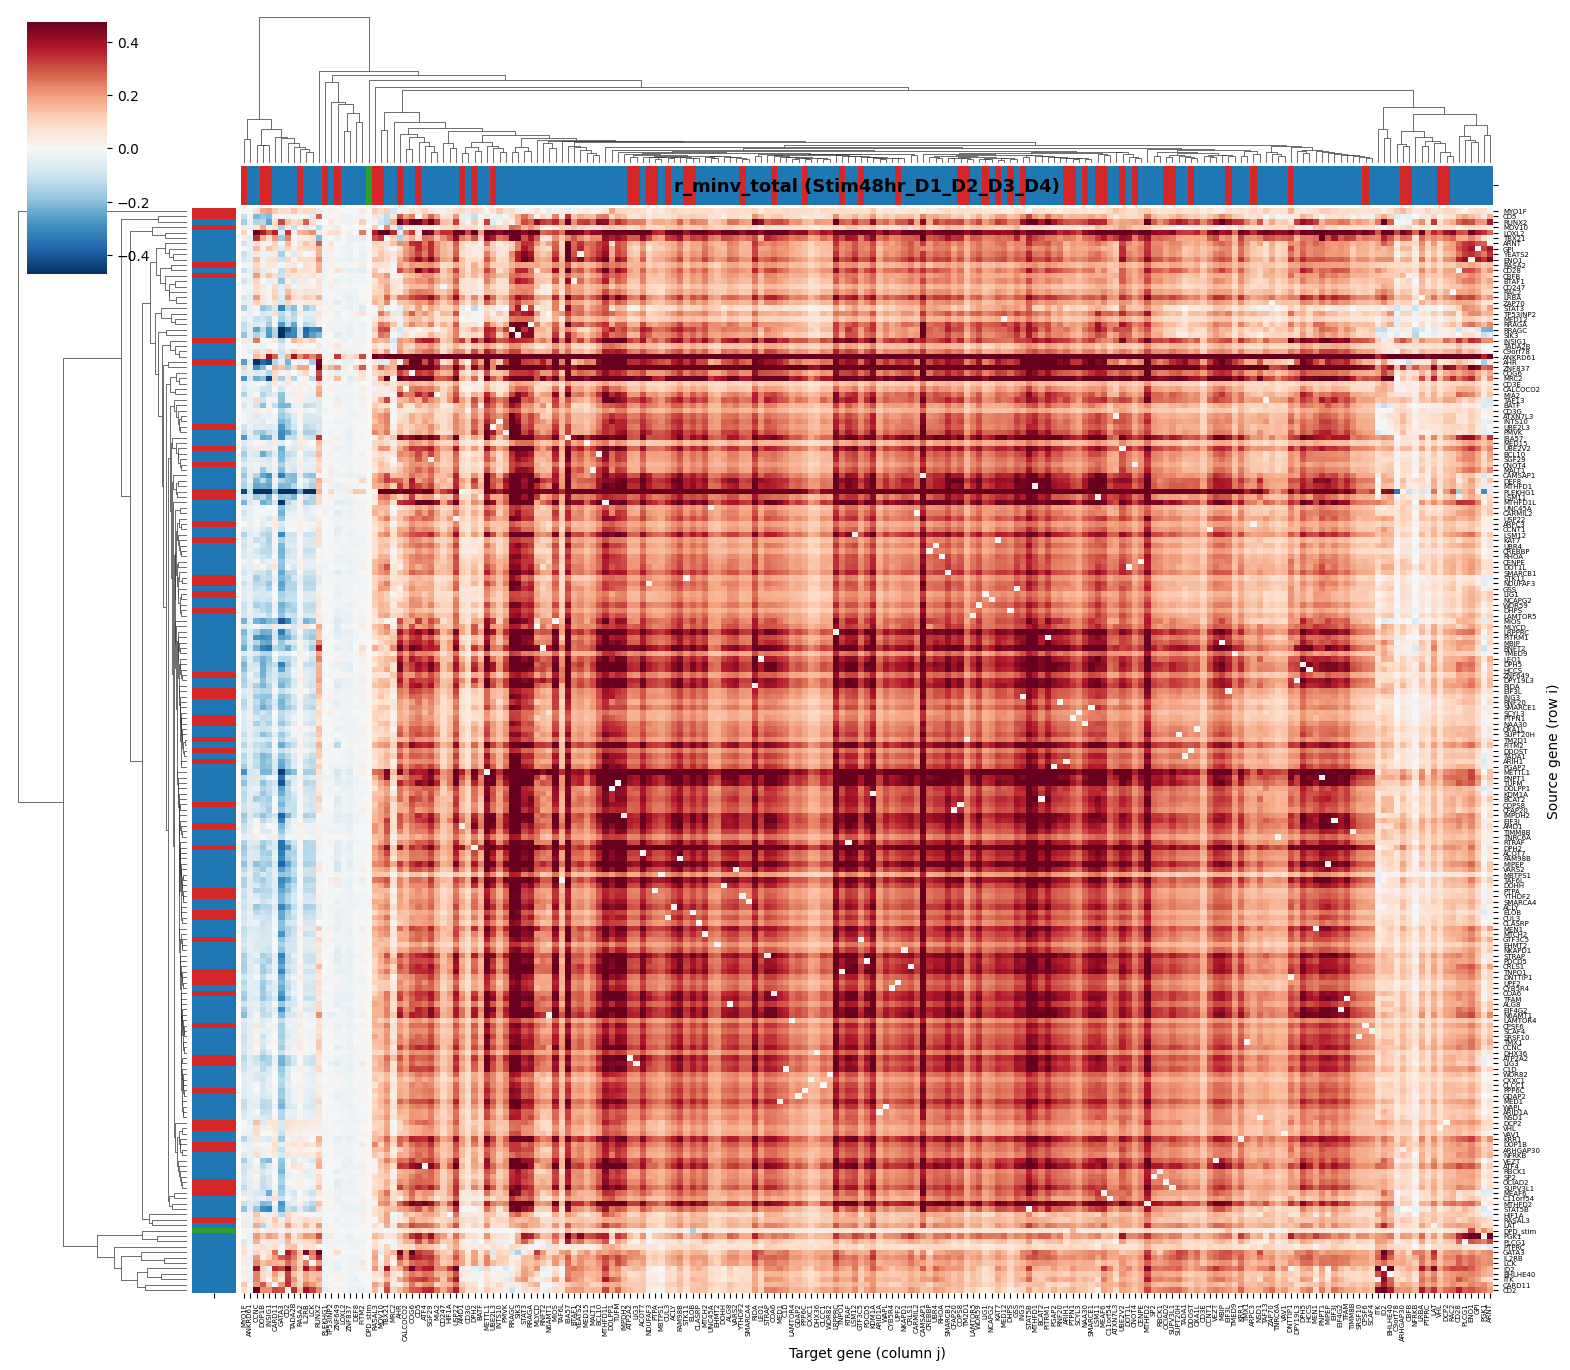

Saved: ../Results/Stim48hr/singlecell/clustermap_rminv_total_Stim48hr_D1_D2_D3_D4.pdf
Saved: ../Results/Stim48hr/singlecell/clustermap_rminv_total_Stim48hr_D1_D2_D3_D4.png


In [6]:
def make_clustermap(r_df, row_colours, title, method, metric, figsize):
    vals = r_df.values
    off_diag = vals[~np.eye(len(vals), dtype=bool)]
    vmax = float(np.percentile(np.abs(off_diag), 95))
    cg = sns.clustermap(
        r_df, method=method, metric=metric,
        cmap='RdBu_r', center=0, vmin=-vmax, vmax=vmax,
        row_colors=row_colours, col_colors=row_colours,
        figsize=figsize, xticklabels=True, yticklabels=True,
        dendrogram_ratio=(0.12, 0.12), colors_ratio=0.03, linewidths=0)
    cg.ax_heatmap.set_title(title, pad=12, fontsize=13, fontweight='bold')
    cg.ax_heatmap.set_xlabel('Target gene (column j)', fontsize=10)
    cg.ax_heatmap.set_ylabel('Source gene (row i)', fontsize=10)
    cg.ax_heatmap.tick_params(axis='both', labelsize=5)
    return cg

print('Generating clustermap...')
cg_rols = make_clustermap(
    r_minv_total, row_colours_df, f'r_minv_total ({run_tag})',
    CLUSTER_METHOD, CLUSTER_METRIC, FIG_SIZE)
plt.show()

for ext, dpi in [('pdf', 150), ('png', 200)]:
    p = os.path.join(OUT_DIR, f'clustermap_rminv_total_{run_tag}.{ext}')
    cg_rols.savefig(p, bbox_inches='tight', dpi=dpi)
    print(f'Saved: {p}')

row_order = r_minv_total.index[cg_rols.dendrogram_row.reordered_ind].tolist()
r_minv_total_clustered = r_minv_total.loc[row_order, row_order]

Standalone dendrogram for the row clustering above.

Saved: ../Results/Stim48hr/singlecell/dendrogram_Stim48hr_D1_D2_D3_D4.png


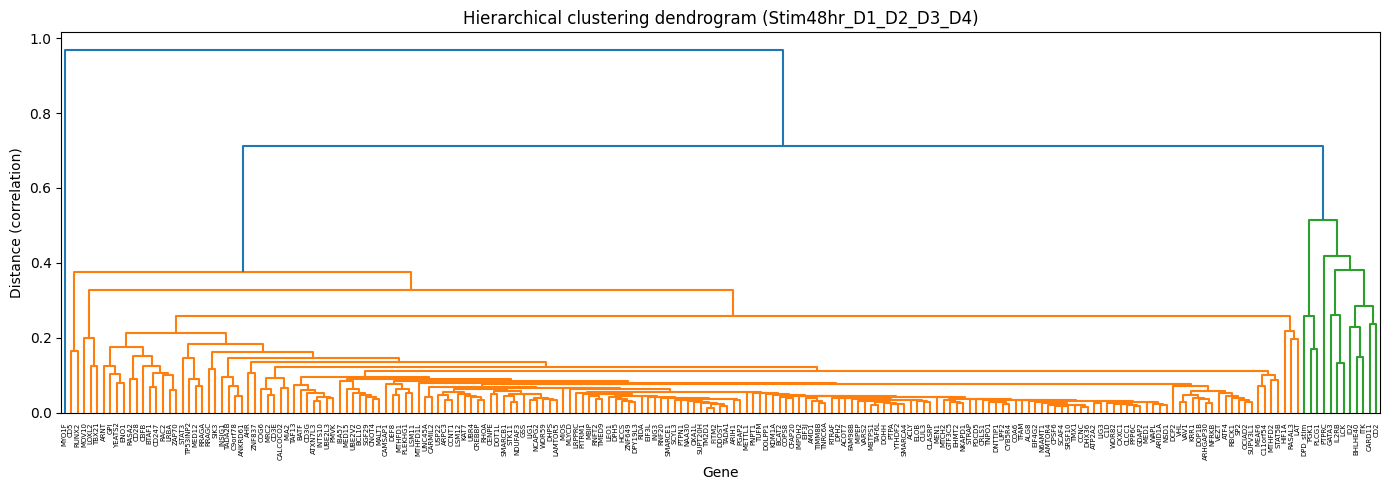

In [7]:
fig, ax = plt.subplots(figsize=(14, 5))
dendrogram(cg_rols.dendrogram_row.linkage, labels=r_minv_total.index.tolist(),
           leaf_rotation=90, leaf_font_size=5, ax=ax)
ax.set_title(f'Hierarchical clustering dendrogram ({run_tag})')
ax.set_xlabel('Gene')
ax.set_ylabel(f'Distance ({CLUSTER_METRIC})')
plt.tight_layout()
p = os.path.join(OUT_DIR, f'dendrogram_{run_tag}.png')
plt.savefig(p, dpi=200, bbox_inches='tight')
print(f'Saved: {p}')
plt.show()

### 4. Cross-Condition External Validation Summary

Loads `validation_string_trrust_{cond_tag}.csv` from Notebook 4 for all three conditions (`ALL_CONDITIONS`), not only the one selected above, this section always compares across conditions regardless of `CONDITION`.

In [8]:
validation_by_condition = []
checkpoint_by_condition = []
for cond in ALL_CONDITIONS:
    cond_tag = f'{cond}_{donors_tag}'
    val_path = os.path.join(f'../Results/{cond}/singlecell', f'validation_string_trrust_{cond_tag}.csv')
    chk_path = os.path.join(f'../Results/{cond}/singlecell', f'validation_checkpoint_genes_{cond_tag}.csv')

    if os.path.exists(val_path):
        df = pd.read_csv(val_path)
        df.insert(0, 'condition', cond)
        validation_by_condition.append(df)
    else:
        print(f'{cond}: validation_string_trrust not found at {val_path} (run Notebook 4 for this condition first)')

    if os.path.exists(chk_path):
        cdf = pd.read_csv(chk_path)
        cdf.insert(0, 'condition', cond)
        checkpoint_by_condition.append(cdf)

validation_cross_condition = pd.concat(validation_by_condition, ignore_index=True) if validation_by_condition else pd.DataFrame()
checkpoint_cross_condition = pd.concat(checkpoint_by_condition, ignore_index=True) if checkpoint_by_condition else pd.DataFrame()

print(f'Loaded validation summaries: {len(validation_by_condition)}/{len(ALL_CONDITIONS)} conditions')
if not validation_cross_condition.empty:
    print(validation_cross_condition.to_string(index=False))

Loaded validation summaries: 3/3 conditions
condition  percentile  n_edges  string_highconf_overlap  string_highconf_pct  string_highconf_pval  string_medconf_overlap  string_medconf_pct  string_medconf_pval  trrust_overlap  trrust_pct  trrust_pval
     Rest          80     7960                       17                  0.2          9.999974e-01                      79                 1.0             1.000000               3         0.0     0.602015
     Rest          90     3980                        6                  0.2          9.999278e-01                      34                 0.9             0.999999               1         0.0     0.794169
     Rest          95     1990                        3                  0.2          9.961754e-01                      14                 0.7             0.999968               0         0.0     1.000000
     Rest          99      398                        0                  0.0          1.000000e+00                       2              

In [9]:
core_by_condition = {}
for cond in ALL_CONDITIONS:
    cond_tag = f'{cond}_{donors_tag}'
    core_path = os.path.join(f'../Results/{cond}', f'core_genes_{cond_tag}.csv')
    if os.path.exists(core_path):
        cdf = pd.read_csv(core_path)
        core_by_condition[cond] = set(cdf['target_contrast_gene_name'])
    else:
        print(f'{cond}: core_genes not found at {core_path}')

all_core_genes = sorted(set().union(*core_by_condition.values()))
presence_df = pd.DataFrame({'gene': all_core_genes})
for cond in ALL_CONDITIONS:
    presence_df[f'core_in_{cond}'] = presence_df['gene'].isin(core_by_condition.get(cond, set()))
presence_df['n_conditions'] = presence_df[[f'core_in_{c}' for c in ALL_CONDITIONS]].sum(axis=1)
presence_df['core_in_conditions'] = presence_df.apply(
    lambda r: [c for c in ALL_CONDITIONS if r[f'core_in_{c}']], axis=1)

print(f'Geni core in almeno una condizione: {len(presence_df)}')
print(presence_df['n_conditions'].value_counts().sort_index())
presence_df.to_csv(os.path.join(OUT_DIR, 'core_gene_presence_cross_condition.csv'), index=False)
print('Saved: core_gene_presence_cross_condition')

Geni core in almeno una condizione: 469
n_conditions
1    354
2     99
3     16
Name: count, dtype: int64
Saved: core_gene_presence_cross_condition


Saved: ../Results/Stim48hr/singlecell/validation_cross_condition_D1_D2_D3_D4.png


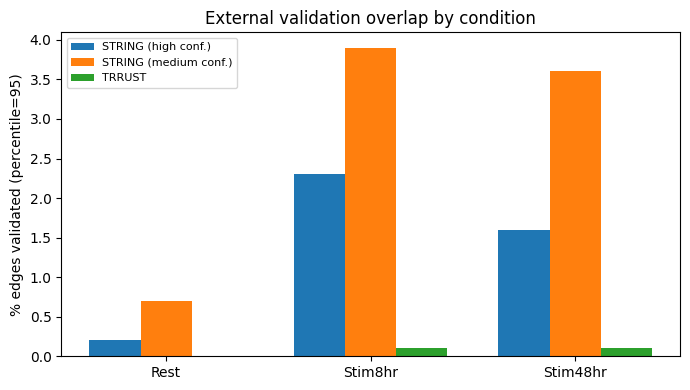

In [10]:
if not validation_cross_condition.empty:
    main_pct = 95
    plot_df = validation_cross_condition[validation_cross_condition['percentile'] == main_pct]
    if not plot_df.empty:
        fig, ax = plt.subplots(figsize=(7, 4))
        x = np.arange(len(plot_df))
        width = 0.25
        ax.bar(x - width, plot_df['string_highconf_pct'], width, label='STRING (high conf.)')
        ax.bar(x, plot_df['string_medconf_pct'], width, label='STRING (medium conf.)')
        ax.bar(x + width, plot_df['trrust_pct'], width, label='TRRUST')
        ax.set_xticks(x)
        ax.set_xticklabels(plot_df['condition'])
        ax.set_ylabel(f'% edges validated (percentile={main_pct})')
        ax.set_title('External validation overlap by condition')
        ax.legend(fontsize=8)
        plt.tight_layout()
        p = os.path.join(OUT_DIR, f'validation_cross_condition_{donors_tag}.png')
        plt.savefig(p, dpi=200, bbox_inches='tight')
        print(f'Saved: {p}')
        plt.show()
    else:
        print(f'No rows at percentile={main_pct}.')

### 5. Gene Importance Rankings

In [11]:
def compute_rankings(r_df, node_table, dpd_col, label):
    genes = list(r_df.index)
    sos = (r_df.values ** 2).sum(axis=1)
    global_rank = pd.Series(sos, index=genes).rank(ascending=False).astype(int)

    off_diag_mask = ~np.eye(len(genes), dtype=bool)
    local_strength = np.array([
        np.abs(r_df.values[i, :][off_diag_mask[i, :]]).mean() for i in range(len(genes))
    ])
    local_rank = pd.Series(local_strength, index=genes).rank(ascending=False).astype(int)

    if dpd_col in node_table.columns:
        dpd_rank = node_table[dpd_col].reindex(genes).abs().rank(ascending=False).astype(int)
    else:
        dpd_rank = pd.Series(np.nan, index=genes)
    rankings = pd.DataFrame({'sum_of_squares': sos,
        'global_importance': global_rank,
        'mean_local_strength': local_strength,
        'local_importance': local_rank,
        'DPD_rank': dpd_rank}, index=genes).sort_values('global_importance')
    print(f'{label} top 20 by global importance:')
    print(rankings.head(20).to_string())
    return rankings

rankings = compute_rankings(r_minv_rols, node_idx, 'DPD_stim_norm', run_tag)

Stim48hr_D1_D2_D3_D4 top 20 by global importance:
         sum_of_squares  global_importance  mean_local_strength  local_importance  DPD_rank
ANKRD61      200.501538                  1             0.929887                 1        57
PLEKHG1      109.946555                  2             0.644326                 2       178
ZNF837        75.108065                  3             0.561221                 3       120
METTL1        52.745565                  4             0.450977                 4        78
MRC2          48.416343                  5             0.438660                 5       119
DPH2          45.790876                  6             0.420148                 7       193
LOXL2         43.382307                  7             0.434310                 6       148
MTHFD1L       34.423764                  8             0.356874                11       100
MIPEP         34.357830                  9             0.363581                 8       117
TUFM          34.291780       

Saved: ../Results/Stim48hr/singlecell/top_genes_global_importance_Stim48hr_D1_D2_D3_D4.png


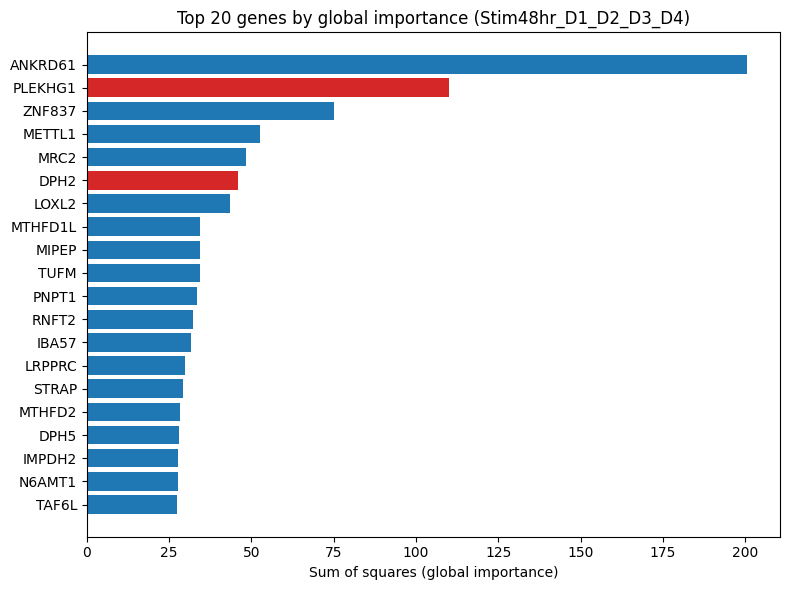

In [12]:
top_n = 20
top = rankings.sort_values('sum_of_squares', ascending=False).head(top_n)
roles = node_idx['role_stim'].reindex(top.index)
colours = ['#d62728' if r == 'activator' else '#1f77b4' for r in roles]

fig, ax = plt.subplots(figsize=(8, max(4, top_n * 0.3)))
ax.barh(top.index[::-1], top['sum_of_squares'][::-1], color=colours[::-1])
ax.set_xlabel('Sum of squares (global importance)')
ax.set_title(f'Top {top_n} genes by global importance ({run_tag})')
plt.tight_layout()
p = os.path.join(OUT_DIR, f'top_genes_global_importance_{run_tag}.png')
plt.savefig(p, dpi=200, bbox_inches='tight')
print(f'Saved: {p}')
plt.show()

### 6. Cluster Membership

Two cuts: N=4 (interpretive, used for GO enrichment) and N=8 (comparison format matching the HUVEC reference). The right number depends on the dendrogram, inspect the clustermap above and adjust `N_CLUSTERS_INTERP` if needed.

In [13]:
def get_clusters(r_df, n_clusters, method, metric, label):
    genes = list(r_df.index)
    dist = pdist(r_df.values, metric=metric)
    Z = linkage(dist, method=method)
    labels = fcluster(Z, t=n_clusters, criterion='maxclust')
    membership = pd.DataFrame({'gene': genes, f'cluster_{label}': labels}).sort_values(f'cluster_{label}')
    print(f'{label} cluster sizes (N={n_clusters}):')
    print(membership[f'cluster_{label}'].value_counts().sort_index().to_string())
    return membership

clusters_4 = get_clusters(r_minv_total, N_CLUSTERS_INTERP, CLUSTER_METHOD, CLUSTER_METRIC, '4')
print()
clusters_8 = get_clusters(r_minv_total, N_CLUSTERS_FULL, CLUSTER_METHOD, CLUSTER_METRIC, '8')

4 cluster sizes (N=4):
cluster_4
1    188
2      3
3      9
4      1

8 cluster sizes (N=8):
cluster_8
1      2
2      3
3    183
4      3
5      3
6      5
7      1
8      1


Saved: ../Results/Stim48hr/singlecell/cluster_sizes_Stim48hr_D1_D2_D3_D4.png


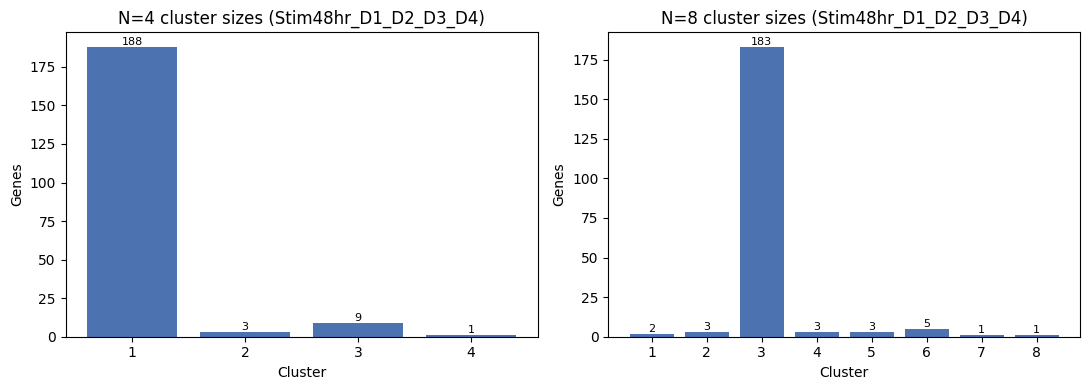

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (df, col, n) in zip(axes,
        [(clusters_4, 'cluster_4', N_CLUSTERS_INTERP),
         (clusters_8, 'cluster_8', N_CLUSTERS_FULL)]):
    sizes = df[col].value_counts().sort_index()
    ax.bar(sizes.index.astype(str), sizes.values, color='#4C72B0')
    ax.set_xlabel('Cluster')
    ax.set_ylabel('Genes')
    ax.set_title(f'N={n} cluster sizes ({run_tag})')
    for i, v in enumerate(sizes.values):
        ax.text(i, v, str(v), ha='center', va='bottom', fontsize=8)
plt.tight_layout()
p = os.path.join(OUT_DIR, f'cluster_sizes_{run_tag}.png')
plt.savefig(p, dpi=200, bbox_inches='tight')
print(f'Saved: {p}')
plt.show()

In [15]:
cluster_table = clusters_4.merge(clusters_8, on='gene')
extra = [c for c in ['DPD_stim_norm', 'role_stim',
                      'out_degree', 'in_degree', 'total_degree']
         if c in node_idx.columns]
cluster_table = cluster_table.merge(node_idx[extra].reset_index(), on='gene', how='left')
print(f'Cluster table: {cluster_table.shape}')
print(cluster_table.head(10).to_string(index=False))

Cluster table: (201, 8)
    gene  cluster_4  cluster_8  DPD_stim_norm role_stim  out_degree  in_degree  total_degree
  ATP2A2          1          3       2.484608 activator         2.0        2.0           4.0
  YTHDF2          1          3       1.586925 activator         0.0        0.0           0.0
   DOP1B          1          3       1.400565 activator        59.0        8.0          67.0
    CUL3          1          3       1.200441 activator         0.0        0.0           0.0
   COPS8          1          3       1.008155 activator         3.0        0.0           3.0
   PPP6C          1          3       0.904473 activator         1.0        0.0           1.0
     CD5          1          1       0.824007 activator        31.0       22.0          53.0
ARHGAP30          1          3       0.819736 activator        11.0        2.0          13.0
  UBE2V2          1          3       0.748519 activator        14.0        7.0          21.0
    LIG3          1          3       0.690765 

### 7. Cluster -> Activation State

Uses `r_minv_total` (the extended global response matrix from Notebook 4, FPTU) to quantify how each cluster of core genes collectively influences the DPD nodes.

**Interpretation:** `r_minv_total[DPD_node, gene]` gives the global effect of perturbing `gene` on `DPD_node`, propagated through the full network. Averaging this over all genes in a cluster gives the mean cluster influence on each DPD node: positive = cluster promotes that state, negative = cluster suppresses it. Skipped if `r_minv_total` is not available.

Cluster -> activation state summary:
 cluster  n_genes DPD_node  mean_influence  std_influence  n_positive  n_negative
       1      188 DPD_stim        0.054101       0.040653         175          13
       2        3 DPD_stim        0.113618       0.089330           2           0
       3        9 DPD_stim        0.048971       0.016828           9           0
       4        1 DPD_stim       -0.009843       0.000000           0           1
Saved: ../Results/Stim48hr/singlecell/cluster_activation_Stim48hr_D1_D2_D3_D4.png


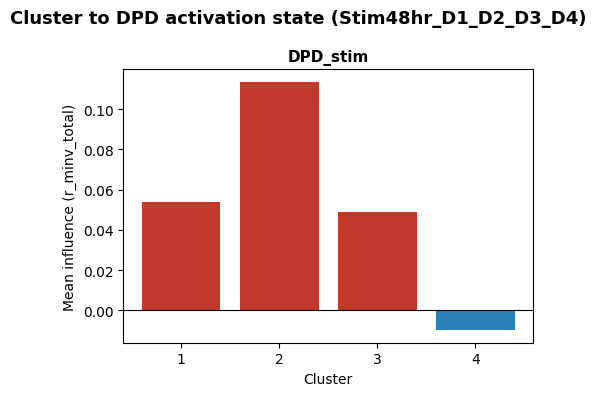

In [16]:
if not FPTU_AVAILABLE:
    print('FPTU_AVAILABLE=False: skipping cluster->activation state analysis.')
else:
    cluster_activation = []
    for cid in sorted(clusters_4['cluster_4'].unique()):
        cluster_genes = clusters_4.loc[clusters_4['cluster_4'] == cid, 'gene'].tolist()
        cluster_genes_in_r = [g for g in cluster_genes if g in r_minv_total.columns]
        if not cluster_genes_in_r:
            continue
        for dpd in DPD_NODES:
            if dpd not in r_minv_total.index:
                continue
            vals = r_minv_total.loc[dpd, cluster_genes_in_r].values.astype(float)
            cluster_activation.append({
                'cluster': cid, 'n_genes': len(cluster_genes_in_r), 'DPD_node': dpd,
                'mean_influence': float(vals.mean()), 'std_influence': float(vals.std()),
                'n_positive': int((vals > 0).sum()), 'n_negative': int((vals < 0).sum()),
            })

    cluster_activation_df = pd.DataFrame(cluster_activation)
    print('Cluster -> activation state summary:')
    print(cluster_activation_df.to_string(index=False))

    dpd_list = cluster_activation_df['DPD_node'].unique().tolist()
    n_dpd = len(dpd_list)
    fig, axes = plt.subplots(1, n_dpd, figsize=(5 * n_dpd, 4), squeeze=False)
    for ax, dpd in zip(axes[0], dpd_list):
        sub = cluster_activation_df[cluster_activation_df['DPD_node'] == dpd]
        colors = ['#c0392b' if v > 0 else '#2980b9' for v in sub['mean_influence']]
        ax.bar(sub['cluster'].astype(str), sub['mean_influence'], color=colors)
        ax.axhline(0, color='black', lw=0.8)
        ax.set_title(dpd, fontsize=11, fontweight='bold')
        ax.set_xlabel('Cluster')
        ax.set_ylabel('Mean influence (r_minv_total)')
    plt.suptitle(f'Cluster to DPD activation state ({run_tag})', fontsize=13, fontweight='bold')
    plt.tight_layout()
    p = os.path.join(OUT_DIR, f'cluster_activation_{run_tag}.png')
    plt.savefig(p, dpi=200, bbox_inches='tight')
    print(f'Saved: {p}')
    plt.show()

### 8. GO Enrichment

- **Set A:** top `N_TOP_DPD` by |DPD_stim_norm|, split by direction (activators and suppressors separately).
- **Set C:** per-cluster gene sets (N=4 cut).

In [17]:
def run_go(gene_list, label, n_top=20):
    if not GPROFILER_OK:
        print(f'gprofiler not available, skipping {label}.')
        return pd.DataFrame()
    if len(gene_list) < 3:
        print(f'{label}: fewer than 3 genes, skipping.')
        return pd.DataFrame()
    gp = GProfiler(return_dataframe=True)
    try:
        res = gp.profile(
            organism=GO_ORGANISM, query=gene_list, sources=GO_SOURCES,
            significance_threshold_method='fdr', user_threshold=GO_FDR,
            no_iea=True, no_evidences=False, ordered=False)
    except Exception as e:
        print(f'{label}: g:Profiler query failed: {e}')
        return pd.DataFrame()
    if res.empty:
        print(f'{label}: no significant terms at FDR <= {GO_FDR}')
        return pd.DataFrame()
    wanted_cols = ['source', 'native', 'name', 'p_value',
                   'term_size', 'query_size', 'intersection_size', 'intersections']
    available_cols = [c for c in wanted_cols if c in res.columns]
    res = res[available_cols].copy()
    res['query_label'] = label
    print(f'{label}: {len(res)} significant terms')
    return res

In [18]:
dpd_sorted = dpd_full.dropna(subset=['DPD_stim_norm']).copy()
dpd_sorted['abs_dpd'] = dpd_sorted['DPD_stim_norm'].abs()
top50 = dpd_sorted.nlargest(N_TOP_DPD, 'abs_dpd')
top50_act = top50[top50['DPD_stim_norm'] > 0]['target_contrast_gene_name'].tolist()
top50_sup = top50[top50['DPD_stim_norm'] < 0]['target_contrast_gene_name'].tolist()
print(f'Top {N_TOP_DPD} DPD: {len(top50_act)} activators, {len(top50_sup)} suppressors')

go_act = run_go(top50_act, 'Top50_activators')
go_sup = run_go(top50_sup, 'Top50_suppressors')

go_cluster_results = []
for cid in sorted(clusters_4['cluster_4'].unique()):
    cluster_genes = clusters_4.loc[clusters_4['cluster_4'] == cid, 'gene'].tolist()
    print(f'\nCluster {cid}: {len(cluster_genes)} genes')
    if len(cluster_genes) < 5:
        print('  Skipping (fewer than 5 genes)')
        continue
    res = run_go(cluster_genes, f'Cluster_{cid}')
    if not res.empty:
        go_cluster_results.append(res)

go_clusters = pd.concat(go_cluster_results) if go_cluster_results else pd.DataFrame()
all_go = pd.concat([df for df in [go_act, go_sup, go_clusters] if not df.empty], ignore_index=True) \
    if any(not df.empty for df in [go_act, go_sup, go_clusters]) else pd.DataFrame()
print(f'\nTotal GO terms across all gene sets: {len(all_go)}')

Top 50 DPD: 1 activators, 49 suppressors
Top50_activators: fewer than 3 genes, skipping.


Top50_suppressors: 568 significant terms

Cluster 1: 188 genes
Cluster_1: 559 significant terms

Cluster 2: 3 genes
  Skipping (fewer than 5 genes)

Cluster 3: 9 genes
Cluster_3: 425 significant terms

Cluster 4: 1 genes
  Skipping (fewer than 5 genes)

Total GO terms across all gene sets: 1552


Top50_activators: no GO results to plot.
Saved: ../Results/Stim48hr/singlecell/GO_barplot_Top50_suppressors_Stim48hr_D1_D2_D3_D4.png


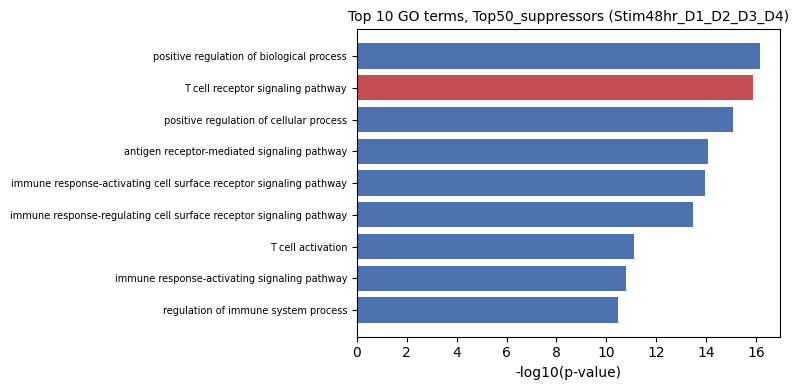

In [19]:
def plot_go_results(go_df, label, top_n=10):
    if go_df.empty:
        print(f'{label}: no GO results to plot.')
        return
    top = go_df.nsmallest(top_n, 'p_value').copy()
    top['neg_log10_p'] = -np.log10(top['p_value'].clip(lower=1e-300))
    top = top.sort_values('neg_log10_p')

    fig, ax = plt.subplots(figsize=(8, max(3, len(top) * 0.4)))
    colours = {'GO:BP': '#4C72B0', 'GO:MF': '#55A868', 'KEGG': '#C44E52', 'REAC': '#8172B2'}
    bar_colours = [colours.get(s, '#888888') for s in top['source']]
    ax.barh(top['name'], top['neg_log10_p'], color=bar_colours)
    ax.set_xlabel('-log10(p-value)')
    ax.set_title(f'Top {len(top)} GO terms, {label} ({run_tag})', fontsize=10)
    ax.tick_params(axis='y', labelsize=7)
    plt.tight_layout()
    p = os.path.join(OUT_DIR, f'GO_barplot_{label}_{run_tag}.png')
    plt.savefig(p, dpi=200, bbox_inches='tight')
    print(f'Saved: {p}')
    plt.show()

plot_go_results(go_act, 'Top50_activators')
plot_go_results(go_sup, 'Top50_suppressors')

In [20]:
gene_go_terms = {g: [] for g in core_genes}
if not all_go.empty and 'intersections' in all_go.columns:
    for _, row in all_go.iterrows():
        hits = row['intersections']
        if not isinstance(hits, list):
            continue
        term_str = f"{row['name']} ({row['query_label']}, p={row['p_value']:.2e})"
        for g in hits:
            if g in gene_go_terms:
                gene_go_terms[g].append(term_str)
else:
    print("No GO intersections available (gprofiler not run, or 'intersections' column missing); go_terms left empty.")

go_terms_series = pd.Series({g: '; '.join(terms) for g, terms in gene_go_terms.items()})
n_go_terms_series = pd.Series({g: len(terms) for g, terms in gene_go_terms.items()})
print(f'Genes with >=1 attributed GO term: {(n_go_terms_series > 0).sum()} / {len(core_genes)}')

Genes with >=1 attributed GO term: 197 / 200


### 9. Master Gene Table

In [21]:
master = nodes_df.copy()

rankings_renamed = rankings[['global_importance', 'mean_local_strength', 'local_importance']].copy()
master = master.merge(rankings_renamed, left_on='gene', right_index=True, how='left')

master = master.merge(cluster_table[['gene', 'cluster_4', 'cluster_8']], on='gene', how='left')

master = master.merge(presence_df[['gene', 'n_conditions', 'core_in_conditions']], on='gene', how='left')

master['go_terms'] = master['gene'].map(go_terms_series).fillna('')
master['n_go_terms'] = master['gene'].map(n_go_terms_series).fillna(0).astype(int)

master = master.sort_values(
    by=['is_checkpoint_gene', 'total_degree'], ascending=[False, False]).reset_index(drop=True)

print(f'Master gene table: {master.shape}')
print(master.head(10).to_string(index=False))

Master gene table: (200, 26)
   gene  DPD_stim_norm  n_sig_genes  ontarget_significant  offtarget_flag  role_stim  out_degree  in_degree  total_degree  r_minv_influence  in_kegg_tcr  in_kegg_wnt  in_kegg_ubiquitin  in_string_highconf  in_string_medconf  in_trrust  is_checkpoint_gene  global_importance  mean_local_strength  local_importance  cluster_4  cluster_8  n_conditions core_in_conditions                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            

### 10. Save

In [22]:
if FPTU_AVAILABLE and 'cluster_activation_df' in dir() and not cluster_activation_df.empty:
    cluster_activation_df.to_csv(os.path.join(OUT_DIR, f'cluster_activation_{run_tag}.csv'), index=False)
    print('Saved: cluster_activation')

r_minv_total_clustered.to_csv(os.path.join(OUT_DIR, f'r_minv_total_clustered_{run_tag}.csv'))
print('Saved: r_minv_total_clustered')

rankings.to_csv(os.path.join(OUT_DIR, f'gene_rankings_{run_tag}.csv'))
print('Saved: gene_rankings')

cluster_table.to_csv(os.path.join(OUT_DIR, f'cluster_membership_{run_tag}.csv'), index=False)
print('Saved: cluster_membership')

if not all_go.empty:
    all_go.to_csv(os.path.join(OUT_DIR, f'GO_enrichment_{run_tag}.csv'), index=False)
    try:
        p_xlsx = os.path.join(OUT_DIR, f'GO_enrichment_{run_tag}.xlsx')
        with pd.ExcelWriter(p_xlsx) as w:
            for label, grp in all_go.groupby('query_label'):
                grp.to_excel(w, sheet_name=str(label)[:31], index=False)
        print('Saved: GO_enrichment.csv and .xlsx')
    except Exception as e:
        print(f'Excel export failed: {e} (CSV still saved)')

master.to_csv(os.path.join(OUT_DIR, f'master_gene_table_{run_tag}.csv'), index=False)
print('Saved: master_gene_table')

print(f'\nDone, {run_tag}')
print(f'Outputs in: {OUT_DIR}')

Saved: cluster_activation
Saved: r_minv_total_clustered
Saved: gene_rankings
Saved: cluster_membership
Saved: GO_enrichment.csv and .xlsx
Saved: master_gene_table

Done, Stim48hr_D1_D2_D3_D4
Outputs in: ../Results/Stim48hr/singlecell
